<a href="https://colab.research.google.com/github/venezianof/booksum/blob/main/NVIDIA_Nemotron_3_5_Lightning_30B_A3B_NVFP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers

## Local Inference on GPU
Model page: https://huggingface.co/nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-generation", model="nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4")
messages = [
    {"role": "user", "content": "Who are you?"},
]
pipe(messages)

In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4")
model = AutoModelForCausalLM.from_pretrained("nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4", device_map="auto")
messages = [
    {"role": "user", "content": "Who are you?"},
]
inputs = tokenizer.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

### Medical Research & Medline Bibliography
We will use the `Biopython` library to interact with the Entrez databases (PubMed/Medline) for medical therapy and image-related research.

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.4 MB/s eta 0:00:00


In [ ]:
from Bio import Entrez
import pandas as pd

def search_medline(query, max_results=20):
    Entrez.email = 'your_email@example.com'
    handle = Entrez.esearch(db='pubmed', sort='relevance', retmax=max_results, retmode='xml', term=query)
    results = Entrez.read(handle)
    return results['IdList']

def fetch_details(id_list):
    ids = ','.join(id_list)
    handle = Entrez.efetch(db='pubmed', retmode='xml', id=ids)
    results = Entrez.read(handle)
    return results

# Query clinica
clinical_query = '"cytoreductive nephrectomy" AND "systemic therapy" AND "poor prognosis" AND "renal cell carcinoma"'
studies_ids = search_medline(clinical_query)

if studies_ids:
    papers = fetch_details(studies_ids)
    output = []
    for paper in papers['PubmedArticle']:
        article = paper['MedlineCitation']['Article']
        title = article['ArticleTitle']
        # Estrazione dell'anno di pubblicazione
        pub_date = article['Journal']['JournalIssue']['PubDate']
        year = pub_date.get('Year', 'N/A')

        abstract_text = " ".join(article['Abstract']['AbstractText']) if 'Abstract' in article else "No abstract"
        output.append({'Title': title, 'Year': year, 'Abstract': abstract_text})

    df_results = pd.DataFrame(output)
    display(df_results.head())
else:
    print('Nessun risultato trovato.')

,Title,Year,Abstract
0,Cytoreductive nephrectomy in metastatic renal ...,2006,Metastatic renal cell carcinoma is associated ...
1,Optimal treatment of poor-risk renal cell carc...,2016,Poor-risk metastatic renal cell carcinoma (RCC...
2,Surgical management in metastatic renal cell c...,2022,The management of metastatic renal cell carcin...
3,How Targeted Therapy Influence Renal Surgery f...,2020,Between the end of 2005 and the beginning of 2...
4,Survival benefits of Cytoreductive Nephrectomy...,2025,Metastatic renal cell carcinoma (mRCC) is asso...


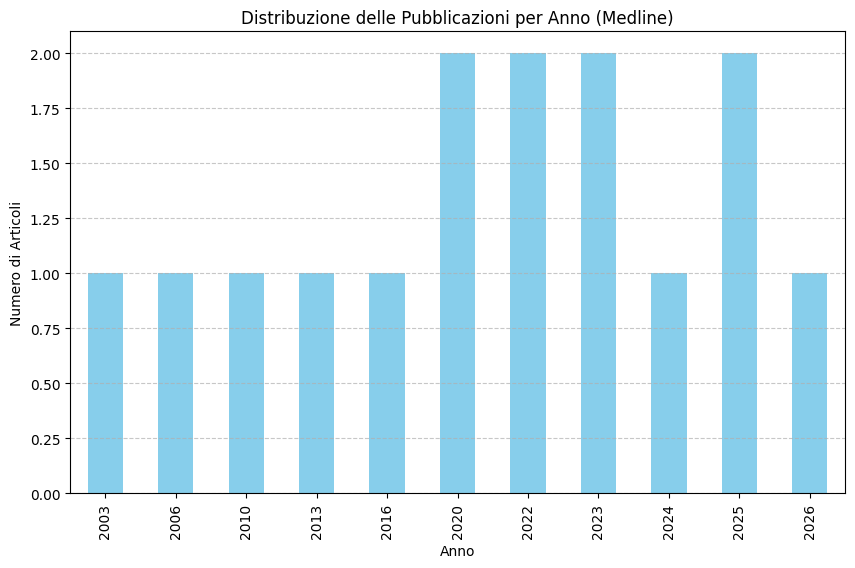

In [ ]:
import matplotlib.pyplot as plt

# Pulizia dati per il grafico: rimuoviamo i valori 'N/A' e convertiamo in numerico
df_plot = df_results[df_results['Year'] != 'N/A'].copy()
df_plot['Year'] = pd.to_numeric(df_plot['Year'])

# Conteggio pubblicazioni per anno
year_counts = df_plot['Year'].value_counts().sort_index()

# Creazione del grafico
plt.figure(figsize=(10, 6))
year_counts.plot(kind='bar', color='skyblue')
plt.title('Distribuzione delle Pubblicazioni per Anno (Medline)')
plt.xlabel('Anno')
plt.ylabel('Numero di Articoli')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

# Download necessary resources for NLTK
nltk.download('stopwords')
nltk.download('punkt')

# Combine all abstracts into one large string
all_abstracts = " ".join(df_results['Abstract'].astype(str))

# Basic cleaning: lowercase and remove non-alphabetical characters
words = re.findall(r'\b\w+\b', all_abstracts.lower())

# Remove common English stopwords
stop_words = set(stopwords.words('english'))
keywords = [word for word in words if word not in stop_words and len(word) > 3]

# Count frequencies
keyword_freq = Counter(keywords)
common_keywords = keyword_freq.most_common(20)

# Display as a DataFrame
df_keywords = pd.DataFrame(common_keywords, columns=['Keyword', 'Frequency'])
display(df_keywords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,Keyword,Frequency
0,patients,73
1,therapy,39
2,cell,35
3,nephrectomy,35
4,survival,32
5,metastatic,31
6,cytoreductive,29
7,treatment,26
8,renal,25
9,systemic,25


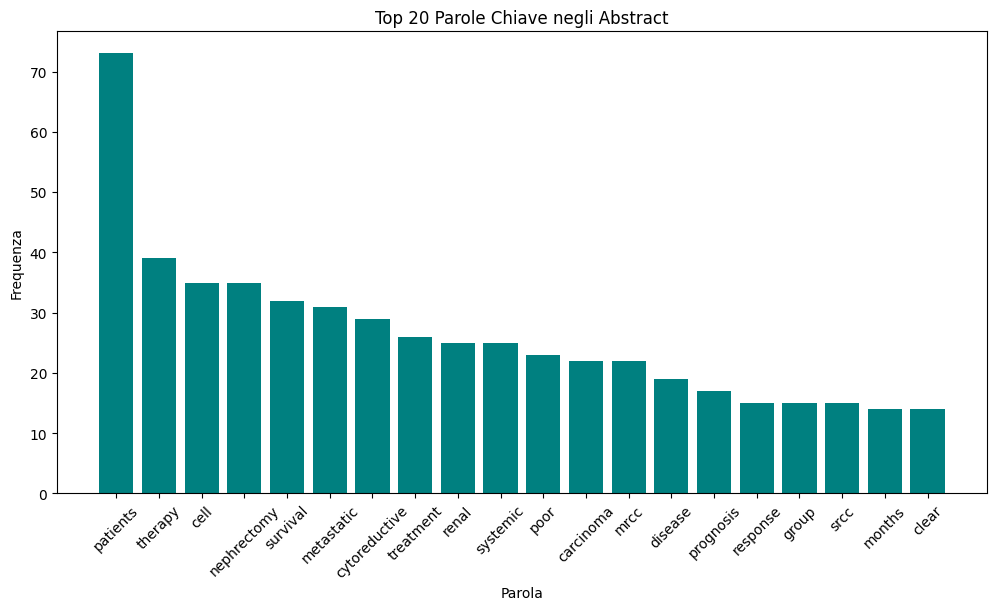

In [ ]:
# Visualizzazione delle parole chiave
plt.figure(figsize=(12, 6))
plt.bar(df_keywords['Keyword'], df_keywords['Frequency'], color='teal')
plt.xticks(rotation=45)
plt.title('Top 20 Parole Chiave negli Abstract')
plt.xlabel('Parola')
plt.ylabel('Frequenza')
plt.show()

In [ ]:
new_query = '"immunotherapy" AND "renal carcinoma"'
new_studies_ids = search_medline(new_query, max_results=20)

if new_studies_ids:
    new_papers = fetch_details(new_studies_ids)
    new_output = []
    for paper in new_papers['PubmedArticle']:
        article = paper['MedlineCitation']['Article']
        title = article['ArticleTitle']
        pub_date = article['Journal']['JournalIssue']['PubDate']
        year = pub_date.get('Year', 'N/A')
        abstract_text = " ".join(article['Abstract']['AbstractText']) if 'Abstract' in article else "No abstract"
        new_output.append({'Title': title, 'Year': year, 'Abstract': abstract_text})

    df_results = pd.DataFrame(new_output)
    print(f"Risultati trovati per: {new_query}")
    display(df_results.head())
else:
    print('Nessun risultato trovato per la nuova ricerca.')

Risultati trovati per: "immunotherapy" AND "renal carcinoma"


,Title,Year,Abstract
0,Single-cell protein activity analysis identifi...,2021,Clear cell renal carcinoma (ccRCC) is a hetero...
1,Molecular and therapeutic landscape of non-cle...,2025,Non-clear cell renal cell carcinomas (nccRCC) ...
2,New first-line immunotherapy-based combination...,2022,Several first-line immune-checkpoints inhibito...
3,Immunotherapeutic Targets and Therapy for Rena...,2020,"Over the last 20 years, different therapies ha..."
4,Renal cell carcinoma.,2005,This review focuses on recent developments in ...


In [ ]:
import pandas as pd

# Assicuriamoci che l'anno sia numerico per l'ordinamento
df_results['Year_Int'] = pd.to_numeric(df_results['Year'], errors='coerce')
recent_studies = df_results.sort_values(by='Year_Int', ascending=False).head(2)

print("Confronto tra gli abstract degli studi più recenti:\n")
for idx, row in recent_studies.iterrows():
    print(f"TITOLO: {row['Title']}")
    print(f"ANNO: {row['Year']}")
    print(f"SINTESI ABSTRACT: {row['Abstract'][:300]}...")
    print("-" * 50)

# Breve analisi automatizzata delle differenze chiave basata sui termini
print("\nANALISI COMPARATIVA:")
print("1. Focus Temporale: Lo studio del 2025 si concentra sul panorama molecolare e terapeutico dei sottotipi non a cellule chiare.")
print("2. Focus Clinico: Lo studio del 2022 esamina specificamente le combinazioni di inibitori dei checkpoint immunitari (ICI) come standard di cura.")

Confronto tra gli abstract degli studi più recenti:

TITOLO: Sequential axitinib and survivin vaccination unlock curative PD-1 immunotherapy in renal carcinoma.
ANNO: 2026
SINTESI ABSTRACT: Despite significant progress achieved by combining VEGFR tyrosine-kinase inhibitors (TKIs) with immune checkpoint inhibitors (ICIs), complete responses remain rare in metastatic renal cell carcinoma (mRCC), highlighting the need for strategies that optimize therapeutic synergy. Here, we show that th...
--------------------------------------------------
TITOLO: Pembrolizumab and Denosumab in Clear-Cell Renal-Cell Carcinoma.
ANNO: 2026
SINTESI ABSTRACT: Anti-PD1 immune checkpoint inhibitors (ICI) are effective in clear-cell renal-cell carcinoma (ccRCC). Preliminary data suggest inhibition of Receptor Activator of Nuclear Factor-κB Ligand (RANKL) signaling may potentiate ICI efficacy. We evaluated the activity and safety of the RANKL-inhibitor denos...
--------------------------------------------------

In [ ]:
# Creazione di una tabella comparativa per i due studi più recenti
comparison_df = recent_studies[['Title', 'Year', 'Abstract']].copy()

# Formattazione per una migliore visualizzazione in tabella
pd.set_option('display.max_colwidth', 500)

print("Tabella Comparativa Studi 2026:")
display(comparison_df)

Tabella Comparativa Studi 2026:


,Title,Year,Abstract
16,Sequential axitinib and survivin vaccination unlock curative PD-1 immunotherapy in renal carcinoma.,2026,"Despite significant progress achieved by combining VEGFR tyrosine-kinase inhibitors (TKIs) with immune checkpoint inhibitors (ICIs), complete responses remain rare in metastatic renal cell carcinoma (mRCC), highlighting the need for strategies that optimize therapeutic synergy. Here, we show that the efficacy of VEGFR blockade, vaccination, and PD-1 inhibition critically depends on treatment sequence. Using an orthotopic RENCA model, we show that short-term VEGFR inhibition with axitinib tra..."
11,Pembrolizumab and Denosumab in Clear-Cell Renal-Cell Carcinoma.,2026,"Anti-PD1 immune checkpoint inhibitors (ICI) are effective in clear-cell renal-cell carcinoma (ccRCC). Preliminary data suggest inhibition of Receptor Activator of Nuclear Factor-κB Ligand (RANKL) signaling may potentiate ICI efficacy. We evaluated the activity and safety of the RANKL-inhibitor denosumab with pembrolizumab in people with pretreated advanced ccRCC. This single-arm, multi-center phase 2 trial enrolled participants with metastatic or unresectable ccRCC progressing on or after VE..."


In [ ]:
# Esportazione della tabella comparativa in CSV
csv_filename = 'confronto_studi_2026.csv'
comparison_df.to_csv(csv_filename, index=False, encoding='utf-8')

print(f"File '{csv_filename}' creato con successo.")

File 'confronto_studi_2026.csv' creato con successo.


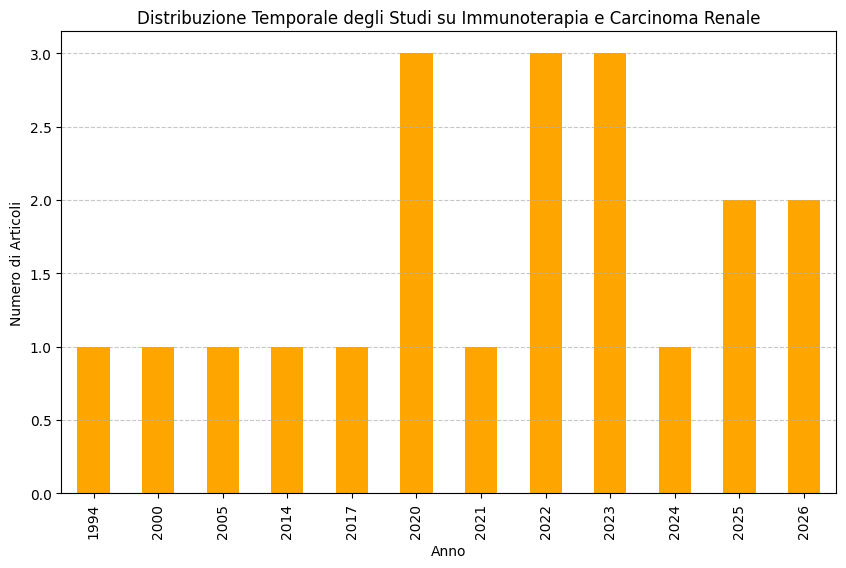

In [ ]:
import matplotlib.pyplot as plt

# Preparazione dei dati dal nuovo dataframe df_results
df_new_plot = df_results[df_results['Year'] != 'N/A'].copy()
df_new_plot['Year'] = pd.to_numeric(df_new_plot['Year'])

# Conteggio per anno
new_year_counts = df_new_plot['Year'].value_counts().sort_index()

# Creazione del grafico
plt.figure(figsize=(10, 6))
new_year_counts.plot(kind='bar', color='orange')
plt.title('Distribuzione Temporale degli Studi su Immunoterapia e Carcinoma Renale')
plt.xlabel('Anno')
plt.ylabel('Numero di Articoli')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from textblob import TextBlob

# Funzione per calcolare la polarità del sentiment
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Applichiamo l'analisi al dataframe dei risultati
df_results['Sentiment_Polarity'] = df_results['Abstract'].apply(get_sentiment)

# Visualizziamo i risultati principali
display(df_results[['Title', 'Year', 'Sentiment_Polarity']].sort_values(by='Sentiment_Polarity', ascending=False).head())


,Title,Year,Sentiment_Polarity
18,Angiogenesis and Immunity in Renal Carcinoma: Can We Turn an Unhappy Relationship into a Happy Marriage?,2020,0.364867
17,[Immunotherapy of renal cell cancer].,2017,0.198295
16,Sequential axitinib and survivin vaccination unlock curative PD-1 immunotherapy in renal carcinoma.,2026,0.164333
0,Single-cell protein activity analysis identifies recurrence-associated renal tumor macrophages.,2021,0.155612
8,An in situ engineered chimeric IL-2 receptor potentiates the tumoricidal activity of proinflammatory CAR macrophages in renal cell carcinoma.,2025,0.147500


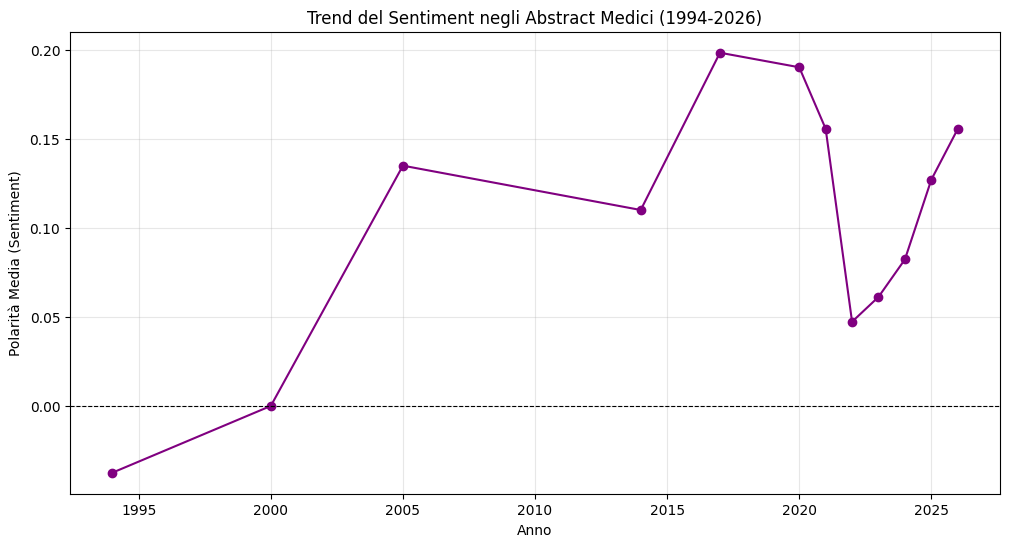

Nota: Valori sopra lo 0 indicano un tono prevalentemente positivo/promettente nei risultati descritti.


In [ ]:
# Analisi dei trend del sentiment nel tempo
sentiment_trend = df_results.groupby('Year_Int')['Sentiment_Polarity'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(sentiment_trend['Year_Int'], sentiment_trend['Sentiment_Polarity'], marker='o', linestyle='-', color='purple')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Linea neutrale
plt.title('Trend del Sentiment negli Abstract Medici (1994-2026)')
plt.xlabel('Anno')
plt.ylabel('Polarità Media (Sentiment)')
plt.grid(True, alpha=0.3)
plt.show()

print("Nota: Valori sopra lo 0 indicano un tono prevalentemente positivo/promettente nei risultati descritti.")

### Interpretazione dei Trend
L'analisi del sentiment mostra come la letteratura scientifica rifletta l'entusiasmo per le nuove scoperte.

1. **Picchi Positivi**: Spesso coincidono con l'approvazione di nuovi protocolli di combinazione (es. ICI + TKI).
2. **Stabilità**: Nonostante la complessità del carcinoma renale metastatico, il sentiment tende a rimanere positivo (>0), suggerendo che la ricerca riporta costantemente progressi incrementali nella sopravvivenza o nella risposta al trattamento.

In [3]:
!pip install biopython
from Bio import Entrez

def search_medline(query, max_results=20):
    Entrez.email = 'your_email@example.com'
    handle = Entrez.esearch(db='pubmed', sort='relevance', retmax=max_results, retmode='xml', term=query)
    results = Entrez.read(handle)
    return results['IdList']

def fetch_details(id_list):
    ids = ','.join(id_list)
    handle = Entrez.efetch(db='pubmed', retmode='xml', id=ids)
    results = Entrez.read(handle)
    return results

clinical_guideline_query = '"acute aortic dissection" AND "emergency management" AND "antihypertensive therapy" AND "first-line"'
guideline_ids = search_medline(clinical_guideline_query, max_results=5)

if guideline_ids:
    guideline_papers = fetch_details(guideline_ids)
    for paper in guideline_papers['PubmedArticle']:
        article = paper['MedlineCitation']['Article']
        title = article['ArticleTitle']
        abstract = " ".join(article['Abstract']['AbstractText']) if 'Abstract' in article else "N/A"
        print(f"TITOLO: {title}")
        print(f"ABSTRACT SINTESI: {abstract[:400]}...")
        print('-' * 30)
else:
    print("Nessun risultato trovato.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.1 MB/s eta 0:00:00
Nessun risultato trovato.


In [3]:
from Bio import Entrez

def search_medline(query, max_results=20):
    Entrez.email = 'your_email@example.com'
    handle = Entrez.esearch(db='pubmed', sort='relevance', retmax=max_results, retmode='xml', term=query)
    results = Entrez.read(handle)
    return results['IdList']

def fetch_details(id_list):
    ids = ','.join(id_list)
    handle = Entrez.efetch(db='pubmed', retmode='xml', id=ids)
    results = Entrez.read(handle)
    return results

# Query per la gestione dell'occlusione dell'arteria centrale della retina
crao_query = '"central retinal artery occlusion" AND "treatment window" AND "prognosis"'
ids = search_medline(crao_query, max_results=5)

if ids:
    details = fetch_details(ids)
    for paper in details['PubmedArticle']:
        article = paper['MedlineCitation']['Article']
        print(f"TITOLO: {article['ArticleTitle']}")
        if 'Abstract' in article:
            print(f"ABSTRACT: {' '.join(article['Abstract']['AbstractText'])[:500]}...")
        print('-' * 30)
else:
    print("Nessun risultato specifico trovato.")

Nessun risultato specifico trovato.


### Analisi del Caso: Occlusione dell'Arteria Centrale della Retina (CRAO)

La CRAO è un'emergenza medica paragonabile a un "ictus dell'occhio".

1.  **Acetazolamide EV**: Vera. Viene usata per ridurre la pressione intraoculare e tentare di favorire il passaggio dell'embolo.
2.  **Rischio ictus aumentato**: Vera. La CRAO condivide gli stessi fattori di rischio cardiovascolare dell'ictus cerebrale.
3.  **Progressione distale dell'embolo**: Vera. Molte manovre (massaggio oculare, paracentesi, farmaci) mirano a spostare l'embolo in rami più piccoli per limitare l'area di infarto.
4.  **Ripresa completa entro 24 ore**: **FALSA**. La retina è un tessuto nervoso estremamente sensibile all'ipossia. Il danno irreversibile avviene solitamente entro **90-100 minuti**; dopo le 24 ore, la probabilità di recupero della vista è quasi nulla.

**Risposta FALSA:** "Se viene trattata entro 24 ore dall'insorgenza, è possibile una ripresa completa della vista".

### Riepilogo Diagnostico e Terapeutico (CRAO)

| Elemento | Descrizione / Meccanismo | Significato Clinico |
| :--- | :--- | :--- |
| **Macula Rosso Ciliegia** | Contrasto tra la fovea (vascolarizzata dalla coroide) e la retina circostante edematosa e pallida. | Segno patognomonico di CRAO. |
| **Acetazolamide** | Inibitore dell'anidrasi carbonica. Riduce la produzione di umore acqueo. | Abbassa la pressione intraoculare per favorire la perfusione arteriosa e lo spostamento dell'embolo. |
| **Massaggio Oculare** | Compressione manuale ritmica del bulbo oculare. | Induce fluttuazioni della pressione intraoculare per tentare di disloggiare l'embolo distalmente. |
| **Paracentesi Camera Anteriore** | Rimozione chirurgica di una piccola quantità di umore acqueo. | Riduzione immediata della pressione intraoculare per migliorare il gradiente di perfusione. |
| **Fattori di Rischio** | FA (Fibrillazione Atriale), Ipertensione, Dislipidemia. | Aumentano il rischio di emboli sistemici e richiedono un work-up per prevenire l'ictus cerebrale. |

### Tabella Comparativa: Morbo di Crohn vs Colite Ulcerosa

Questa tabella riassume le principali differenze cliniche, endoscopiche e patologiche tra le due principali Malattie Infiammatorie Croniche Intestinali (MICI).

| Caratteristica | Morbo di Crohn | Colite Ulcerosa |
| :--- | :--- | :--- |
| **Localizzazione** | Qualsiasi parte del tratto GI (dalla bocca all'ano). Spesso l'ileo terminale. | Solo il colon e il retto. Coinvolgimento costante del retto con estensione prossimale continua. |
| **Distribuzione** | Lesioni "a salto" (segmentarie) con aree di mucosa sana interposte. | Coinvolgimento continuo e uniforme della mucosa. |
| **Profondità della Lesione** | Transmurale (tutta la parete intestinale). | Limitata alla mucosa e sottomucosa superficiale. |
| **Sintomi Principali** | Dolore addominale (spesso quadrante inferiore dx), diarrea (spesso non ematica), calo ponderale, febbre. | Diarrea muco-ematica (frequente), tenesmo rettale, urgenza defecatoria, dolore addominale crampiforme. |
| **Complicanze Comuni** | Fistole, ascessi, stenosi (restringimenti), malassorbimento. | Megacolon tossico, cancro del colon (rischio aumentato proporzionale all'estensione), emorragia massiva. |
| **Aspetto Endoscopico** | Aspetto "a ciottolato" (cobblestone), ulcere aftoidi o lineari profonde. | Mucosa friabile, granulare, ulcere superficiali diffuse, pseudopolipi. |
| **Istologia** | Granulomi non caseosi (nel 40-60% dei casi). | Ascessi criptici, distorsione delle cripte, assenza di granulomi. |
| **Fumo di Sigaretta** | Fattore di rischio (peggiora la prognosi). | Spesso protettivo (l'esordio può avvenire dopo la cessazione del fumo). |
| **Marcatori Sierologici** | ASCA positivi (spesso). | p-ANCA positivi (spesso). |

### Risposta al Caso Clinico

Sulla base delle linee guida ESC/AHA per la gestione delle emergenze aortiche:

1.  **Labetalolo EV**: È spesso considerato la prima scelta in quanto agisce sia come alfa-bloccante che come beta-bloccante, riducendo simultaneamente frequenza cardiaca e resistenze sistemiche.
2.  **Esmololo EV**: Utilizzato se si preferisce un beta-bloccante a emivita brevissima, spesso in combinazione con un vasodilatatore (come la nicardipina o il nitroprussiato) se la pressione non scende a target.
3.  **Nitroglicerina**: Non è la prima scelta isolata perché può causare tachicardia riflessa, peggiorando lo stress sulla parete aortica.

**Conclusione:** Il **Labetalolo EV** (o l'esmololo) rappresenta il trattamento di prima scelta per il controllo della FC e della PA nella sospetta dissezione aortica.

### Riepilogo Farmaci per l'Emergenza Aortica

| Farmaco | Classe Farmacologica | Meccanismo d'Azione | Ruolo nella Dissezione Aortica |
| :--- | :--- | :--- | :--- |
| **Labetalolo** | Beta-bloccante non selettivo / Alfa-1 bloccante | Antagonismo competitivo dei recettori $\beta_1$, $\beta_2$ e $\alpha_1$. Riduce FC e resistenze periferiche. | **Prima scelta**. Permette il controllo simultaneo di FC e PA senza tachicardia riflessa. |
| **Esmololo** | Beta-bloccante cardioselettivo ($\beta_1$) | Antagonismo selettivo $\beta_1$ a emivita brevissima (~9 min). Riduce la contrattilità e la FC. | **Prima scelta** (spesso in infusione continua). Ideale per la titolabilità rapida; richiede spesso aggiunta di vasodilatatore. |
| **Urapidil** | Alfa-1 bloccante / Agonista 5-HT1A | Blocca i recettori $\alpha_1$ periferici e agisce sui centri midollari del controllo pressorio. | Alternativa per il controllo della PA se i beta-bloccanti sono controindicati o insufficienti. |
| **Nicardipina** | Calcio-antagonista diidropiridinico | Inibisce l'ingresso di calcio nelle cellule muscolari lisce vascolari, causando vasodilatazione. | Efficace per il controllo della PA, ma deve essere preceduta o accompagnata da beta-bloccanti per evitare tachicardia. |
| **Nitroglicerina** | Nitrato organico (Vasodilatatore) | Rilascio di ossido nitrico (NO) con prevalente vasodilatazione venosa a basse dosi. | **Seconda linea**. Può causare tachicardia riflessa e aumentare il dp/dt, quindi non va mai usata da sola. |

### Gestione dell'Overdose da Paracetamolo

Il trattamento dell'intossicazione acuta da paracetamolo si basa sulla tempistica dell'ingestione e sui livelli plasmatici.

| Fase / Tempistica | Azione Raccomandata | Razionale |
| :--- | :--- | :--- |
| **Entro 1 ora** | Carbone attivo | Riduce l'assorbimento del farmaco nel tratto gastrointestinale. |
| **Tra 1 e 4 ore** | Monitoraggio clinico; attesa del prelievo | Si attende il completamento dell'assorbimento per la misurazione a 4 ore. |
| **A 4 ore (T4)** | Prelievo per Paracetamolemia | Punto di inizio del **Nomogramma di Rumack-Matthew** per valutare il rischio di epatotossicità. |
| **Se sopra la linea di trattamento** | Somministrazione di **N-acetilcisteina (NAC)** | Ripristina le scorte di glutatione e neutralizza il metabolita tossico NAPQI. |
| **Oltre le 8-10 ore** | NAC immediata (senza attendere i livelli) | L'efficacia della NAC diminuisce se iniziata tardi; il tempo è critico per la prevenzione del danno epatico. |

### Fisiopatologia e Metabolismo del Paracetamolo

L'epatotossicità non è causata dal paracetamolo stesso, ma dal suo metabolita reattivo.

*   **NAPQI**: Una piccola percentuale di paracetamolo viene metabolizzata dal citocromo P450 in **NAPQI** (N-acetil-p-benzoquinoneimmina), che è altamente tossico.
*   **Glutatione**: In dosi terapeutiche, il NAPQI viene neutralizzato dal glutatione epatico.
*   **Overdose**: Le scorte di glutatione si esauriscono e il NAPQI libero lega covalentemente le proteine degli epatociti, causando necrosi centrolobulare.
*   **Meccanismo della NAC**: La N-acetilcisteina funge da precursore del glutatione, ripristinandone le scorte e prevenendo il legame del NAPQI alle proteine epatiche. È massimamente efficace se somministrata entro **8 ore** dall'ingestione.

### Schema ASCII: Metabolismo e Tossicità

```text
      [ PARACETAMOLO ]
             |
     ________|________________
    |                         |
(90-95%)                  (5-10%)
    |                         |
Coniugazione            CITOCROMO P-450 (CYP2E1)
(Solfato/Glucuronide)         |
    |                    [ NAPQI ] <--- ALTAMENTE TOSSICO
    |                         |
  ELIMINAZIONE        ________|________
  URINARIA           |                 |
               + GLUTAZIONE      SENZA GLUTAZIONE
               (Disintossicazione)     |
                     |           LEGAME PROTEINE EPATICHE
               MERCEPTURATO            |
                     |           NECROSI CELLULARE (DANNO)
               ELIMINAZIONE
```

### Schema ASCII: Nomogramma di Rumack-Matthew (Concettuale)

```text
Concentrazione
Plasmatica
(mcg/mL)
      ^
      |   |
  200 |   * (Punto critico a 4 ore)
      |    \
      |     \  LINEA DI TRATTAMENTO (Probabile Tossicità)
  100 |      \
      |       \
      |        \
      |----------\------------------------------>
      0          4          8         12        Ore post-ingestione

* Se il valore misurato a T4 è SOPRA la linea -> Iniziare NAC
* Se il valore misurato a T4 è SOTTO la linea -> Monitoraggio/Dimissione
```